# COMPAS Recidivism Dataset — EDA Summary (with Code & Visuals)

This notebook summarizes the key findings, features, and exploratory data analysis performed on the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) dataset, originally investigated by ProPublica. Created with the help of Copilot

**Datasets used:**
- `compas-scores-two-years.csv` — Filtered dataset for two-year general recidivism analysis
- `compas-scores-two-years-violent.csv` — Violent recidivism subset
- `cox-parsed.csv` / `cox-violent-parsed.csv` — Survival analysis datasets

**Primary research question:** Does the COMPAS risk assessment tool exhibit racial bias in predicting recidivism?

In [1]:
# Install required dependencies
!pip install seaborn statsmodels lifelines missingno scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# --- Setup & Dependencies ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import glm

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

---
## 1. Data Loading & Cleaning

The raw dataset has ~7,214 rows. We apply 4 cleaning filters to produce a usable **6,172-row** dataset.

In [5]:
# Load raw data
df = pd.read_csv("./datasets/compas-analysis/compas-scores-two-years.csv")
print(f"Raw dataset shape: {df.shape}")

# Select relevant columns
cleaned_df = df[["age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
                 "priors_count", "days_b_screening_arrest", "decile_score",
                 "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"]].copy()

# FILTER 1: Charge date within +/-30 days of screening
cleaned_df = cleaned_df[(cleaned_df["days_b_screening_arrest"] <= 30) &
                        (cleaned_df["days_b_screening_arrest"] >= -30)]
print(f"After +/-30 day filter: {len(cleaned_df)}")

# FILTER 2: Remove missing COMPAS cases (is_recid == -1)
cleaned_df = cleaned_df[cleaned_df["is_recid"] != -1]
print(f"After removing missing cases: {len(cleaned_df)}")

# FILTER 3: Remove ordinary traffic offenses
cleaned_df = cleaned_df[cleaned_df["c_charge_degree"] != "O"]
print(f"After removing traffic offenses: {len(cleaned_df)}")

# FILTER 4: Remove N/A scores
cleaned_df = cleaned_df[cleaned_df["score_text"] != 'N/A']
print(f"Final cleaned dataset: {len(cleaned_df)} rows")

Raw dataset shape: (7214, 53)
After +/-30 day filter: 6172
After removing missing cases: 6172
After removing traffic offenses: 6172
Final cleaned dataset: 6172 rows


---
## 2. Demographic Breakdown

Understanding who is in the dataset before analyzing bias.

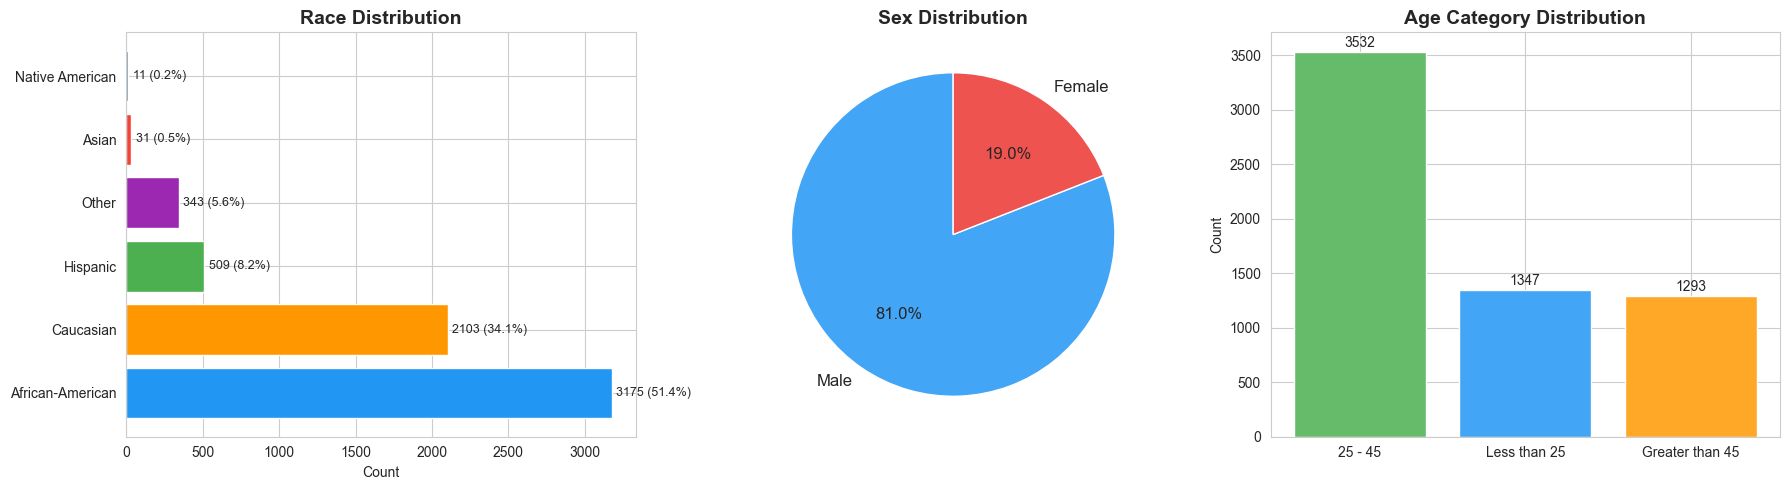


--- Score Text Distribution ---
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

--- Race x Sex Crosstab ---
sex               Female  Male
race                          
African-American     549  2626
Asian                  2    29
Caucasian            482  1621
Hispanic              82   427
Native American        2     9
Other                 58   285


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Race Distribution ---
race_counts = cleaned_df["race"].value_counts()
colors_race = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#607D8B']
bars = axes[0].barh(race_counts.index, race_counts.values, color=colors_race, edgecolor='white')
axes[0].set_title("Race Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Count")
for bar, val in zip(bars, race_counts.values):
    pct = val / len(cleaned_df) * 100
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=9)

# --- Sex Distribution ---
sex_counts = cleaned_df["sex"].value_counts()
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#42A5F5', '#EF5350'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Sex Distribution", fontsize=14, fontweight='bold')

# --- Age Category Distribution ---
age_counts = cleaned_df["age_cat"].value_counts()
axes[2].bar(age_counts.index, age_counts.values, color=['#66BB6A', '#42A5F5', '#FFA726'], edgecolor='white')
axes[2].set_title("Age Category Distribution", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Count")
for i, (val, idx) in enumerate(zip(age_counts.values, age_counts.index)):
    axes[2].text(i, val + 40, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Score Text Distribution ---")
print(cleaned_df["score_text"].value_counts())
print(f"\n--- Race x Sex Crosstab ---")
print(pd.crosstab(cleaned_df["race"], cleaned_df["sex"]))

---
## 3. Feature Engineering: Length of Stay & Correlation with COMPAS Score

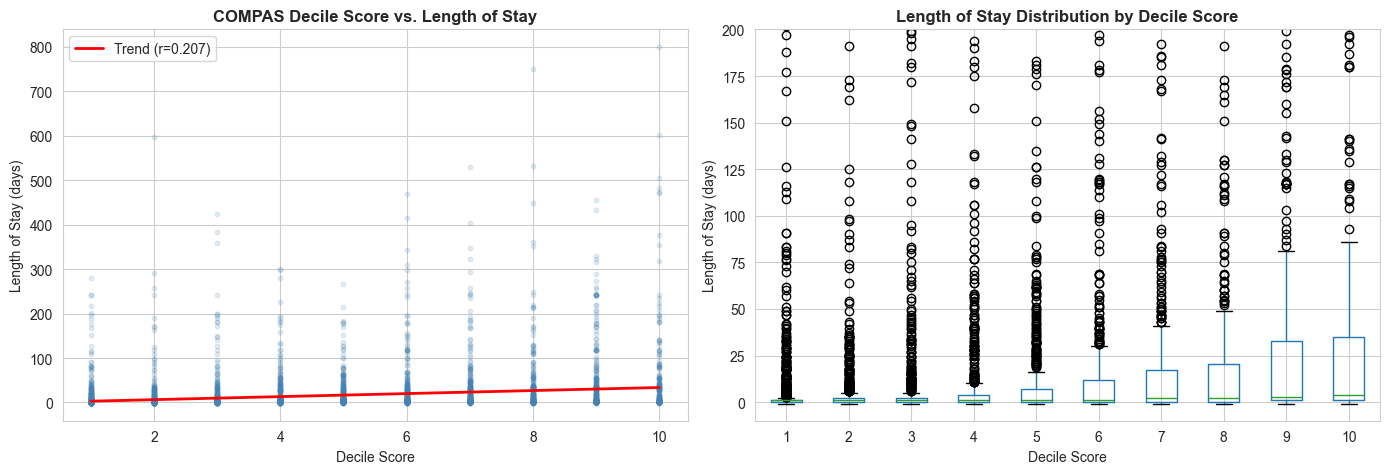


Pearson correlation (length_of_stay vs decile_score): 0.2075
Higher COMPAS scores are slightly correlated with longer jail stays.


In [7]:
# Derive length_of_stay
cleaned_df["c_jail_in"] = pd.to_datetime(cleaned_df["c_jail_in"])
cleaned_df["c_jail_out"] = pd.to_datetime(cleaned_df["c_jail_out"])
cleaned_df["length_of_stay"] = (cleaned_df["c_jail_out"] - cleaned_df["c_jail_in"]).dt.days

correlation = cleaned_df["length_of_stay"].corr(cleaned_df["decile_score"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with trend line
axes[0].scatter(cleaned_df["decile_score"], cleaned_df["length_of_stay"],
                alpha=0.15, s=10, color='steelblue')
z = np.polyfit(cleaned_df["decile_score"].dropna(), cleaned_df["length_of_stay"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(1, 10, 100)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend (r={correlation:.3f})')
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Length of Stay (days)")
axes[0].set_title("COMPAS Decile Score vs. Length of Stay", fontweight='bold')
axes[0].legend()

# Box plot by decile
cleaned_df.boxplot(column='length_of_stay', by='decile_score', ax=axes[1])
axes[1].set_title("Length of Stay Distribution by Decile Score", fontweight='bold')
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Length of Stay (days)")
axes[1].set_ylim(-10, 200)
plt.suptitle("")

plt.tight_layout()
plt.show()

print(f"\nPearson correlation (length_of_stay vs decile_score): {correlation:.4f}")
print("Higher COMPAS scores are slightly correlated with longer jail stays.")

---
## 4. COMPAS Decile Score Distribution by Race

One of the most important visual findings — the shape of score distributions differs dramatically between Black and White defendants.

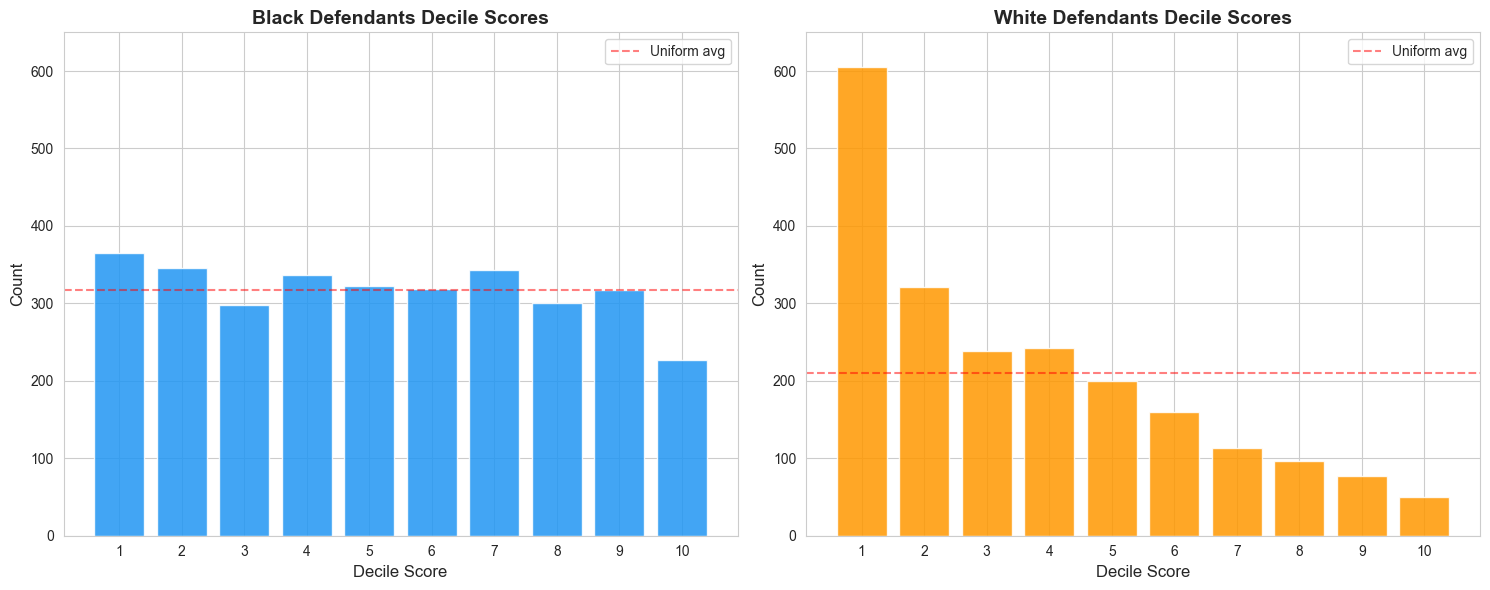

Key observation:
  Black defendants: relatively flat distribution across 1-10
  White defendants: strong downward trend, most score 1-3, very few score 8-10

  Black defendants with score >= 7: 1188 (37.4%)
  White defendants with score >= 7: 336 (16.0%)


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Black defendants
black_df = cleaned_df[cleaned_df["race"] == "African-American"]
black_counts = black_df["decile_score"].value_counts().sort_index()
ax1.bar(black_counts.index, black_counts.values, color='#2196F3', edgecolor='white', alpha=0.85)
ax1.set_xlabel("Decile Score", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_ylim(0, 650)
ax1.set_title("Black Defendants Decile Scores", fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 11))
ax1.axhline(y=len(black_df)/10, color='red', linestyle='--', alpha=0.5, label='Uniform avg')
ax1.legend()

# White defendants
white_df = cleaned_df[cleaned_df["race"] == "Caucasian"]
white_counts = white_df["decile_score"].value_counts().sort_index()
ax2.bar(white_counts.index, white_counts.values, color='#FF9800', edgecolor='white', alpha=0.85)
ax2.set_xlabel("Decile Score", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_ylim(0, 650)
ax2.set_title("White Defendants Decile Scores", fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, 11))
ax2.axhline(y=len(white_df)/10, color='red', linestyle='--', alpha=0.5, label='Uniform avg')
ax2.legend()

plt.tight_layout()
plt.show()

print("Key observation:")
print("  Black defendants: relatively flat distribution across 1-10")
print("  White defendants: strong downward trend, most score 1-3, very few score 8-10")
print(f"\n  Black defendants with score >= 7: {len(black_df[black_df['decile_score'] >= 7])} "
      f"({len(black_df[black_df['decile_score'] >= 7]) / len(black_df) * 100:.1f}%)")
print(f"  White defendants with score >= 7: {len(white_df[white_df['decile_score'] >= 7])} "
      f"({len(white_df[white_df['decile_score'] >= 7]) / len(white_df) * 100:.1f}%)")

---
## 5. Racial Bias — Logistic Regression (General Recidivism)

We fit a logistic regression predicting whether a defendant received a Medium/High COMPAS score (vs. Low), **controlling for** criminal history, charge severity, and actual recidivism. If COMPAS were unbiased, race should not be a significant predictor after controlling for these factors.

In [9]:
# Prepare model data
df_model = cleaned_df.copy()
df_model['crime_factor'] = pd.Categorical(df_model['c_charge_degree'])

age_categories = sorted(df_model['age_cat'].unique().tolist())
df_model['age_factor'] = pd.Categorical(df_model['age_cat'],
    categories=['25 - 45'] + [c for c in age_categories if c != '25 - 45'])

race_categories = sorted(df_model['race'].unique().tolist())
df_model['race_factor'] = pd.Categorical(df_model['race'],
    categories=['Caucasian'] + [c for c in race_categories if c != 'Caucasian'])

df_model['gender_factor'] = pd.Categorical(df_model['sex'], categories=['Male', 'Female'])

# Binary outcome: Low vs Medium/High
df_model['score_factor'] = (df_model['score_text'] != 'Low').map({False: 'LowScore', True: 'HighScore'})
df_model['score_factor'] = pd.Categorical(df_model['score_factor'])

# Fit logistic regression
model = glm(
    formula='score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid',
    data=df_model,
    family=sm.families.Binomial()
)
result = model.fit()
print(result.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[HighScore]', 'score_factor[LowScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Fri, 06 Mar 2026   Deviance:                       6168.4
Time:                                                           12:05:57   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

GENERAL RECIDIVISM: ODDS RATIOS (controlling for confounders)
  Intercept (control probability): 0.1786

  Black vs. White:    OR = 1.4528  -> 45.3% more likely to receive higher score
  Female vs. Male:    OR = 1.1948  -> 19.5% more likely to receive higher score
  Under 25 vs. 25-45: OR = 2.4961  -> 2.5x more likely to receive higher score


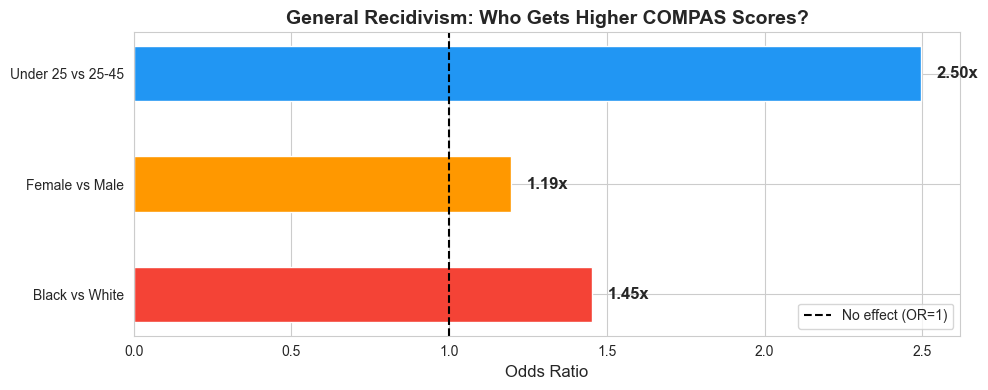

In [10]:
# --- Calculate and visualize odds ratios from the logistic regression ---
intercept = result.params['Intercept']
control = np.exp(intercept) / (1 + np.exp(intercept))

# Extract key coefficients
coef_black = result.params.get('race_factor[T.African-American]', 0)
coef_female = result.params.get('gender_factor[T.Female]', 0)
coef_young = result.params.get('age_factor[T.Less than 25]', 0)

# Calculate odds ratios using the formula from ProPublica
or_black = np.exp(coef_black) / (1 - control + (control * np.exp(coef_black)))
or_female = np.exp(coef_female) / (1 - control + (control * np.exp(coef_female)))
or_young = np.exp(coef_young) / (1 - control + (control * np.exp(coef_young)))

print("=" * 60)
print("GENERAL RECIDIVISM: ODDS RATIOS (controlling for confounders)")
print("=" * 60)
print(f"  Intercept (control probability): {control:.4f}")
print(f"\n  Black vs. White:    OR = {or_black:.4f}  -> {(or_black-1)*100:.1f}% more likely to receive higher score")
print(f"  Female vs. Male:    OR = {or_female:.4f}  -> {(or_female-1)*100:.1f}% more likely to receive higher score")
print(f"  Under 25 vs. 25-45: OR = {or_young:.4f}  -> {or_young:.1f}x more likely to receive higher score")

# Visualize odds ratios
fig, ax = plt.subplots(figsize=(10, 4))
labels = ['Black vs White', 'Female vs Male', 'Under 25 vs 25-45']
odds_ratios = [or_black, or_female, or_young]
colors = ['#F44336', '#FF9800', '#2196F3']
bars = ax.barh(labels, odds_ratios, color=colors, edgecolor='white', height=0.5)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='No effect (OR=1)')
for bar, val in zip(bars, odds_ratios):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel("Odds Ratio", fontsize=12)
ax.set_title("General Recidivism: Who Gets Higher COMPAS Scores?", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 6. Racial Bias — Logistic Regression (Violent Recidivism)

The same analysis applied to violent recidivism scores shows even larger disparities.

VIOLENT RECIDIVISM: ODDS RATIOS
  Black vs. White:    OR = 1.7739  -> 77.4% overprediction
  Under 25 vs. 25-45: OR = 7.41  -> 7.4x more likely to receive higher score


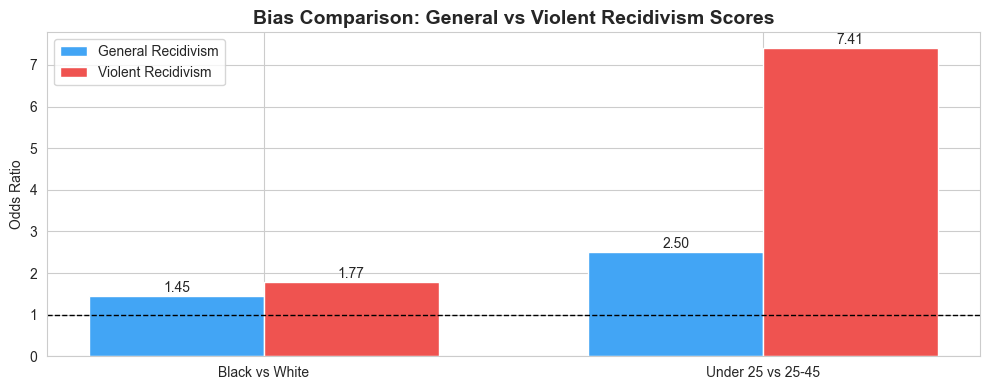

In [11]:
# Load and clean violent recidivism data
df_vi = pd.read_csv("./datasets/compas-analysis/compas-scores-two-years-violent.csv")
cleaned_df_vi = df_vi[["age", "c_charge_degree", "race", "age_cat", "v_score_text", "sex",
                        "priors_count", "days_b_screening_arrest", "v_decile_score",
                        "is_recid", "two_year_recid"]].copy()

cleaned_df_vi = cleaned_df_vi[(cleaned_df_vi["days_b_screening_arrest"] <= 30) &
                              (cleaned_df_vi["days_b_screening_arrest"] >= -30)]
cleaned_df_vi = cleaned_df_vi[cleaned_df_vi["is_recid"] != -1]
cleaned_df_vi = cleaned_df_vi[cleaned_df_vi["c_charge_degree"] != "O"]
cleaned_df_vi = cleaned_df_vi[cleaned_df_vi["v_score_text"] != 'N/A']

# Prepare model
df_model_vi = cleaned_df_vi.copy()
df_model_vi['crime_factor'] = pd.Categorical(df_model_vi['c_charge_degree'])
df_model_vi['age_factor'] = pd.Categorical(df_model_vi['age_cat'],
    categories=['25 - 45', 'Less than 25', 'Greater than 45'])
df_model_vi['race_factor'] = pd.Categorical(df_model_vi['race'],
    categories=['Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other'])
df_model_vi['gender_factor'] = pd.Categorical(df_model_vi['sex'], categories=['Male', 'Female'])
df_model_vi['score_factor'] = pd.Categorical(
    (df_model_vi['v_score_text'] != 'Low').map({True: 'LowScore', False: 'HighScore'}),
    categories=['LowScore', 'HighScore'])

model_vi = glm(
    formula='score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid',
    data=df_model_vi, family=sm.families.Binomial())
result_vi = model_vi.fit()

# Calculate odds ratios
intercept_vi = result_vi.params['Intercept']
control_vi = np.exp(intercept_vi) / (1 + np.exp(intercept_vi))
coef_black_vi = result_vi.params.get('race_factor[T.African-American]', 0)
coef_young_vi = result_vi.params.get('age_factor[T.Less than 25]', 0)

or_black_vi = np.exp(coef_black_vi) / (1 - control_vi + (control_vi * np.exp(coef_black_vi)))
or_young_vi = np.exp(coef_young_vi) / (1 - control_vi + (control_vi * np.exp(coef_young_vi)))

print("=" * 60)
print("VIOLENT RECIDIVISM: ODDS RATIOS")
print("=" * 60)
print(f"  Black vs. White:    OR = {or_black_vi:.4f}  -> {(or_black_vi-1)*100:.1f}% overprediction")
print(f"  Under 25 vs. 25-45: OR = {or_young_vi:.2f}  -> {or_young_vi:.1f}x more likely to receive higher score")

# Side-by-side comparison: General vs Violent
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [or_black, or_young], width, label='General Recidivism', color='#42A5F5')
bars2 = ax.bar(x + width/2, [or_black_vi, or_young_vi], width, label='Violent Recidivism', color='#EF5350')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(['Black vs White', 'Under 25 vs 25-45'])
ax.set_ylabel("Odds Ratio")
ax.set_title("Bias Comparison: General vs Violent Recidivism Scores", fontsize=14, fontweight='bold')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Predictive Accuracy — Cox Proportional Hazards Model

We assess how well COMPAS actually predicts recidivism using survival analysis (Cox PH). Northpointe (COMPAS creator) reported 68% concordance in their validation study.

In [12]:
from lifelines import CoxPHFitter, KaplanMeierFitter

# Load and clean cox data
cox_data = pd.read_csv("./datasets/compas-analysis/cox-parsed.csv")
cox_data = cox_data[(cox_data["score_text"] != "N/A") & (cox_data["end"] > cox_data["start"])]
cox_data["score_factor"] = pd.Categorical(cox_data["score_text"], categories=["Low", "Medium", "High"])

# --- Model 1: Score categories (Low/Medium/High) ---
cox_cat = pd.get_dummies(cox_data[["start", "end", "event", "score_text"]].copy(),
                          columns=["score_text"], drop_first=False)
cph_cat = CoxPHFitter()
cph_cat.fit(cox_cat[["start", "end", "event", "score_text_Medium", "score_text_High"]],
            duration_col="end", event_col="event", entry_col="start")

# --- Model 2: Decile score (continuous) ---
cph_decile = CoxPHFitter()
cph_decile.fit(cox_data[['start', 'end', 'event', 'decile_score']],
               duration_col='end', event_col='event', entry_col="start")

print("=" * 60)
print("COX PH MODEL: SCORE CATEGORIES (Low as reference)")
print("=" * 60)
print(cph_cat.summary[['coef', 'exp(coef)', 'p']])
print(f"\nConcordance: {cph_cat.concordance_index_:.3f}")

print(f"\n{'=' * 60}")
print("COX PH MODEL: DECILE SCORE (continuous)")
print("=" * 60)
print(cph_decile.summary[['coef', 'exp(coef)', 'p']])
print(f"\nConcordance: {cph_decile.concordance_index_:.3f}")

print(f"\n--- Accuracy Comparison ---")
print(f"  COMPAS categories concordance:  {cph_cat.concordance_index_:.1%}")
print(f"  COMPAS decile concordance:      {cph_decile.concordance_index_:.1%}")
print(f"  Northpointe's claimed accuracy: 68.0%")
print(f"  -> COMPAS underperforms its own validation study.")

COX PH MODEL: SCORE CATEGORIES (Low as reference)
                       coef  exp(coef)              p
covariate                                            
score_text_Medium  0.796990   2.218853   3.788139e-85
score_text_High    1.250383   3.491681  5.799725e-200

Concordance: 0.600

COX PH MODEL: DECILE SCORE (continuous)
                  coef  exp(coef)              p
covariate                                       
decile_score  0.194837   1.215113  6.048095e-248

Concordance: 0.621

--- Accuracy Comparison ---
  COMPAS categories concordance:  60.0%
  COMPAS decile concordance:      62.1%
  Northpointe's claimed accuracy: 68.0%
  -> COMPAS underperforms its own validation study.


---
## 8. Kaplan-Meier Survival Curves (Overall, by Race, by Gender)

Survival curves show how quickly defendants in each risk category reoffend, and whether this pattern holds across races and genders.

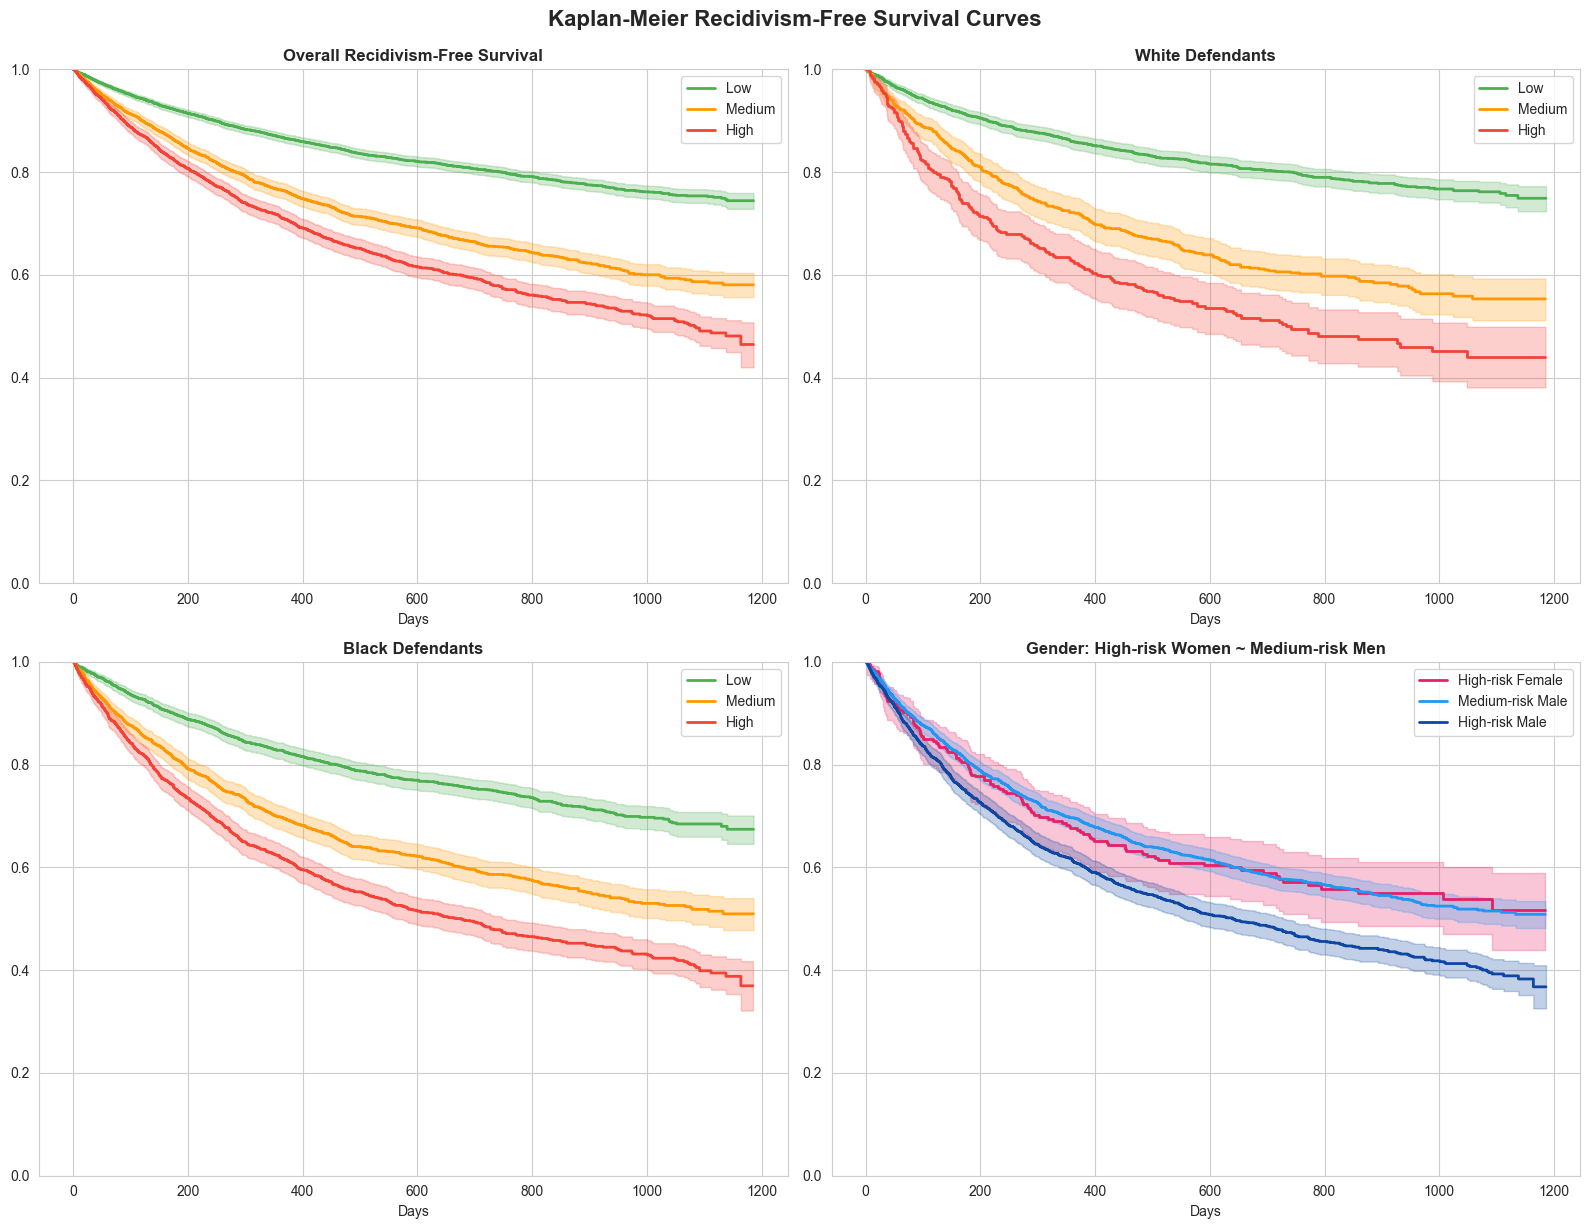

In [13]:
def collapse_to_one_per_id(df):
    """Collapse counting-process rows to one row per subject for KM estimation"""
    return df.groupby('id').agg({'end': 'max', 'event': 'max',
                                  'score_text': 'first', 'race': 'first',
                                  'sex': 'first'}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
risk_colors = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

# --- Overall KM ---
for score_label in ['Low', 'Medium', 'High']:
    w = cox_data[cox_data['score_text'] == score_label]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=w['end'], event_observed=w['event'], label=score_label)
    kmf.plot_survival_function(ax=axes[0, 0], color=risk_colors[score_label], linewidth=2)
axes[0, 0].set_title('Overall Recidivism-Free Survival', fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_xlabel('Days')

# --- White defendants KM ---
white_cx = collapse_to_one_per_id(cox_data[cox_data['race'] == 'Caucasian'])
for score_label in ['Low', 'Medium', 'High']:
    w = white_cx[white_cx['score_text'] == score_label]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=w['end'], event_observed=w['event'], label=score_label)
    kmf.plot_survival_function(ax=axes[0, 1], color=risk_colors[score_label], linewidth=2)
axes[0, 1].set_title('White Defendants', fontweight='bold')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_xlabel('Days')

# --- Black defendants KM ---
black_cx = collapse_to_one_per_id(cox_data[cox_data['race'] == 'African-American'])
for score_label in ['Low', 'Medium', 'High']:
    b = black_cx[black_cx['score_text'] == score_label]
    kmf = KaplanMeierFitter()
    kmf.fit(durations=b['end'], event_observed=b['event'], label=score_label)
    kmf.plot_survival_function(ax=axes[1, 0], color=risk_colors[score_label], linewidth=2)
axes[1, 0].set_title('Black Defendants', fontweight='bold')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_xlabel('Days')

# --- Gender comparison: High-risk women vs Medium-risk men ---
female_cx = collapse_to_one_per_id(cox_data[cox_data['sex'] == 'Female'])
male_cx = collapse_to_one_per_id(cox_data[cox_data['sex'] == 'Male'])
for lbl, subset, clr in [('High-risk Female', female_cx[female_cx['score_text']=='High'], '#E91E63'),
                          ('Medium-risk Male', male_cx[male_cx['score_text']=='Medium'], '#2196F3'),
                          ('High-risk Male', male_cx[male_cx['score_text']=='High'], '#0D47A1')]:
    kmf = KaplanMeierFitter()
    kmf.fit(durations=subset['end'], event_observed=subset['event'], label=lbl)
    kmf.plot_survival_function(ax=axes[1, 1], color=clr, linewidth=2)
axes[1, 1].set_title('Gender: High-risk Women ~ Medium-risk Men', fontweight='bold')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel('Days')

plt.tight_layout()
plt.suptitle("Kaplan-Meier Recidivism-Free Survival Curves", fontsize=16, fontweight='bold', y=1.02)
plt.show()

---
## 9. Cox PH with Race x Score Interaction

Testing whether COMPAS scores have **different predictive validity** for different racial groups.

HAZARD RATIOS: Race x Score Interaction (vs Low risk)
  White High-risk HR: 3.61  (High scores predict well for whites)
  Black High-risk HR: 2.98  (High scores predict less well for blacks)
  White Medium-risk HR: 2.33
  Black Medium-risk HR: 1.95


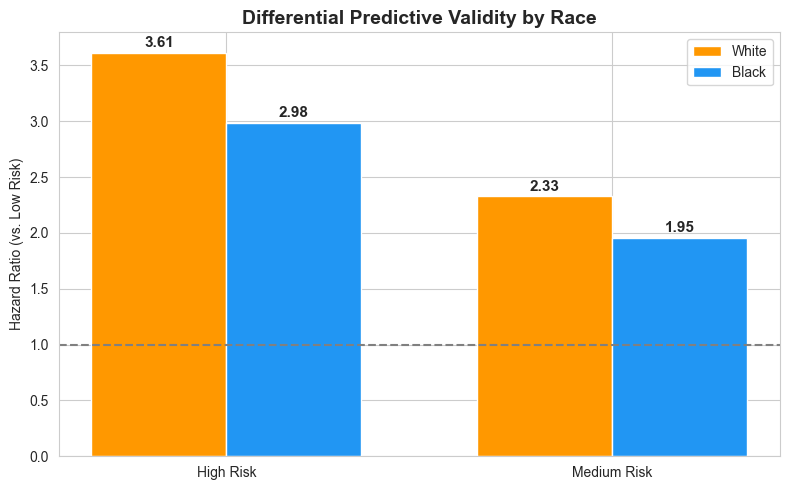


-> COMPAS High scores are MORE predictive for White defendants than for Black defendants.
   The algorithm produces different levels of accuracy depending on race.


In [14]:
import math

# Build interaction model manually with dummy variables
cox_data_int = cox_data.copy()
cox_data_int["race_factor"] = pd.Categorical(
    cox_data_int["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"])
cox_data_int["score_factor"] = pd.Categorical(
    cox_data_int["score_text"], categories=["Low", "Medium", "High"])

cox_data_int = pd.get_dummies(cox_data_int, columns=["race_factor", "score_factor"], drop_first=True)

# Create interaction terms (race x score)
race_cols = [c for c in cox_data_int.columns if c.startswith('race_factor_')]
score_cols = [c for c in cox_data_int.columns if c.startswith('score_factor_')]
for r in race_cols:
    for s in score_cols:
        cox_data_int[f"{r}:{s}"] = cox_data_int[r] * cox_data_int[s]

feature_cols = race_cols + score_cols + [c for c in cox_data_int.columns if ':' in c]
cph_int = CoxPHFitter()
cph_int.fit(cox_data_int[["start", "end", "event"] + feature_cols],
            duration_col="end", event_col="event", entry_col="start")

# Extract hazard ratios for key comparison
coef_high = cph_int.params_.get('score_factor_High', 0)
coef_black_high = cph_int.params_.get('race_factor_African-American:score_factor_High', 0)
coef_med = cph_int.params_.get('score_factor_Medium', 0)
coef_black_med = cph_int.params_.get('race_factor_African-American:score_factor_Medium', 0)

white_high_hr = math.exp(coef_high)
black_high_hr = math.exp(coef_high + coef_black_high)
white_med_hr = math.exp(coef_med)
black_med_hr = math.exp(coef_med + coef_black_med)

print("=" * 60)
print("HAZARD RATIOS: Race x Score Interaction (vs Low risk)")
print("=" * 60)
print(f"  White High-risk HR: {white_high_hr:.2f}  (High scores predict well for whites)")
print(f"  Black High-risk HR: {black_high_hr:.2f}  (High scores predict less well for blacks)")
print(f"  White Medium-risk HR: {white_med_hr:.2f}")
print(f"  Black Medium-risk HR: {black_med_hr:.2f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [white_high_hr, white_med_hr], width, label='White', color='#FF9800')
bars2 = ax.bar(x + width/2, [black_high_hr, black_med_hr], width, label='Black', color='#2196F3')
ax.set_xticks(x)
ax.set_xticklabels(['High Risk', 'Medium Risk'])
ax.set_ylabel("Hazard Ratio (vs. Low Risk)")
ax.set_title("Differential Predictive Validity by Race", fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n-> COMPAS High scores are MORE predictive for White defendants than for Black defendants.")
print("   The algorithm produces different levels of accuracy depending on race.")

---
## 10. Classification Error Rates — Confusion Matrix Analysis

Using the cox-parsed survival data, we build confusion matrices (Low vs. Medium/High) and compute false positive rates (FPR) and false negative rates (FNR) by race. This is the most direct measure of COMPAS's disparate impact.

In [15]:
from csv import DictReader

# --- Helper classes to parse cox data per-person ---
class PeekyReader:
    def __init__(self, reader):
        self.peeked = None
        self.reader = reader
    def peek(self):
        if self.peeked is None:
            self.peeked = next(self.reader)
        return self.peeked
    def __iter__(self):
        return self
    def __next__(self):
        if self.peeked is not None:
            ret = self.peeked
            self.peeked = None
            return ret
        try:
            return next(self.reader)
        except StopIteration:
            self.peeked = None
            raise StopIteration

class Person:
    def __init__(self, reader):
        self.__rows = []
        self.__idx = reader.peek()['id']
        try:
            while reader.peek()['id'] == self.__idx:
                self.__rows.append(next(reader))
        except StopIteration:
            pass
    @property
    def lifetime(self):
        return sum(int(r['end']) - int(r['start']) for r in self.__rows)
    @property
    def recidivist(self):
        return self.__rows[0]['is_recid'] == "1" and self.lifetime <= 730
    @property
    def violent_recidivist(self):
        return self.__rows[0]['is_violent_recid'] == "1" and self.lifetime <= 730
    @property
    def low(self):
        return self.__rows[0]['score_text'] == "Low"
    @property
    def high(self):
        return not self.low
    @property
    def vlow(self):
        return self.__rows[0]['v_score_text'] == "Low"
    @property
    def vhigh(self):
        return not self.vlow
    @property
    def score(self):
        return self.__rows[0]['score_text']
    @property
    def vscore(self):
        return self.__rows[0]['v_score_text']
    @property
    def race(self):
        return self.__rows[0]['race']
    @property
    def valid(self):
        return (self.__rows[0]['is_recid'] != "-1" and
                (self.recidivist and self.lifetime <= 730) or self.lifetime > 730)
    @property
    def score_valid(self):
        return self.score in ["Low", "Medium", "High"]
    @property
    def vscore_valid(self):
        return self.vscore in ["Low", "Medium", "High"]

# Load people from cox-parsed data
people = []
with open("datasets/compas-analysis/cox-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

pop = [i for i in people if i.score_valid and
       ((i.recidivist and i.lifetime <= 730) or i.lifetime > 730)]
recid = [i for i in pop if i.recidivist and i.lifetime <= 730]
rset = set(recid)
surv = [i for i in pop if i not in rset]

print(f"Total population: {len(pop)}")
print(f"Recidivists: {len(recid)}")
print(f"Survived (no recidivism): {len(surv)}")

Total population: 7214
Recidivists: 3251
Survived (no recidivism): 3963


In [16]:
def compute_rates(recid_list, surv_list, prefix=''):
    """Compute confusion matrix metrics from person lists"""
    low_attr = prefix + 'low'
    high_attr = prefix + 'high'
    tn = len([i for i in surv_list if getattr(i, low_attr)])
    fp = len([i for i in surv_list if getattr(i, high_attr)])
    fn = len([i for i in recid_list if getattr(i, low_attr)])
    tp = len([i for i in recid_list if getattr(i, high_attr)])
    total = tn + fp + fn + tp
    fpr = fp / (tn + fp) * 100 if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    accuracy = (tn + tp) / total * 100 if total > 0 else 0
    ppv = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    return {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
            'fpr': fpr, 'fnr': fnr, 'accuracy': accuracy,
            'ppv': ppv, 'npv': npv, 'total': total}

is_afam = lambda x: x.race == "African-American"
is_white = lambda x: x.race == "Caucasian"

all_rates = compute_rates(recid, surv)
black_rates = compute_rates(list(filter(is_afam, recid)), list(filter(is_afam, surv)))
white_rates = compute_rates(list(filter(is_white, recid)), list(filter(is_white, surv)))

# Print confusion matrices
print("=" * 70)
print("GENERAL RECIDIVISM: CONFUSION MATRIX ANALYSIS (Low vs Med/High)")
print("=" * 70)
for label, rates in [("All Defendants", all_rates),
                      ("Black Defendants", black_rates),
                      ("White Defendants", white_rates)]:
    print(f"\n  {label} (n={rates['total']}):")
    print(f"              Predicted Low   Predicted High")
    print(f"    Survived:  TN={rates['tn']:>5}        FP={rates['fp']:>5}")
    print(f"    Recidiv:   FN={rates['fn']:>5}        TP={rates['tp']:>5}")
    print(f"    FPR = {rates['fpr']:.2f}%  |  FNR = {rates['fnr']:.2f}%  |  Accuracy = {rates['accuracy']:.2f}%")
    print(f"    PPV = {rates['ppv']:.2f}%  |  NPV = {rates['npv']:.2f}%")

fpr_ratio = black_rates['fpr'] / white_rates['fpr']
fnr_ratio = white_rates['fnr'] / black_rates['fnr']
print(f"\n{'=' * 70}")
print(f"  FPR disparity (Black/White): {fpr_ratio:.2f}x")
print(f"  -> Black defendants are {(fpr_ratio-1)*100:.0f}% more likely to be FALSE POSITIVES")
print(f"     (scored high risk but did NOT reoffend)")
print(f"\n  FNR disparity (White/Black): {fnr_ratio:.2f}x")
print(f"  -> White defendants are {(fnr_ratio-1)*100:.0f}% more likely to be FALSE NEGATIVES")
print(f"     (scored low risk but DID reoffend)")

GENERAL RECIDIVISM: CONFUSION MATRIX ANALYSIS (Low vs Med/High)

  All Defendants (n=7214):
              Predicted Low   Predicted High
    Survived:  TN= 2681        FP= 1282
    Recidiv:   FN= 1216        TP= 2035
    FPR = 32.35%  |  FNR = 37.40%  |  Accuracy = 65.37%
    PPV = 61.35%  |  NPV = 68.80%

  Black Defendants (n=3696):
              Predicted Low   Predicted High
    Survived:  TN=  990        FP=  805
    Recidiv:   FN=  532        TP= 1369
    FPR = 44.85%  |  FNR = 27.99%  |  Accuracy = 63.83%
    PPV = 62.97%  |  NPV = 65.05%

  White Defendants (n=2454):
              Predicted Low   Predicted High
    Survived:  TN= 1139        FP=  349
    Recidiv:   FN=  461        TP=  505
    FPR = 23.45%  |  FNR = 47.72%  |  Accuracy = 66.99%
    PPV = 59.13%  |  NPV = 71.19%

  FPR disparity (Black/White): 1.91x
  -> Black defendants are 91% more likely to be FALSE POSITIVES
     (scored high risk but did NOT reoffend)

  FNR disparity (White/Black): 1.71x
  -> White defenda

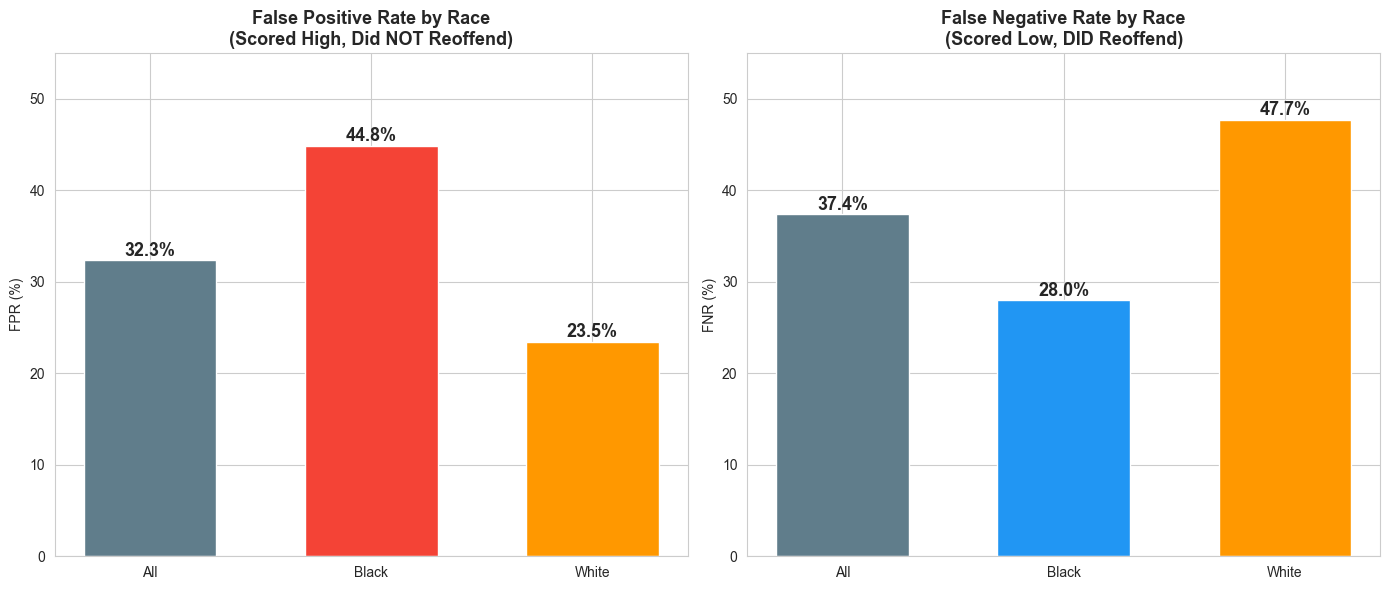

In [17]:
# --- Visualize error rate disparities ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FPR comparison
groups = ['All', 'Black', 'White']
fprs = [all_rates['fpr'], black_rates['fpr'], white_rates['fpr']]
colors_fpr = ['#607D8B', '#F44336', '#FF9800']
bars1 = axes[0].bar(groups, fprs, color=colors_fpr, edgecolor='white', width=0.6)
axes[0].set_title("False Positive Rate by Race\n(Scored High, Did NOT Reoffend)",
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel("FPR (%)")
for bar, val in zip(bars1, fprs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 55)

# FNR comparison
fnrs = [all_rates['fnr'], black_rates['fnr'], white_rates['fnr']]
colors_fnr = ['#607D8B', '#2196F3', '#FF9800']
bars2 = axes[1].bar(groups, fnrs, color=colors_fnr, edgecolor='white', width=0.6)
axes[1].set_title("False Negative Rate by Race\n(Scored Low, DID Reoffend)",
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel("FNR (%)")
for bar, val in zip(bars2, fnrs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

In [18]:
# --- Violent Recidivism Error Rates ---
vpeople = []
with open("datasets/compas-analysis/cox-violent-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass

vpop = [i for i in vpeople if i.vscore_valid and
        ((i.violent_recidivist and i.lifetime <= 730) or i.lifetime > 730)]
vrecid = [i for i in vpop if i.violent_recidivist and i.lifetime <= 730]
vrset = set(vrecid)
vsurv = [i for i in vpop if i not in vrset]

all_v = compute_rates(vrecid, vsurv, prefix='v')
black_v = compute_rates(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)), prefix='v')
white_v = compute_rates(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)), prefix='v')

print("=" * 70)
print("VIOLENT RECIDIVISM: ERROR RATES")
print("=" * 70)
for label, rates in [("All", all_v), ("Black", black_v), ("White", white_v)]:
    print(f"  {label}: FPR={rates['fpr']:.2f}%  FNR={rates['fnr']:.2f}%")

v_fpr_ratio = black_v['fpr'] / white_v['fpr']
v_fnr_ratio = white_v['fnr'] / black_v['fnr']
print(f"\n  Black/White FPR ratio: {v_fpr_ratio:.2f}x")
print(f"  -> Black defendants ~2x more likely to be violent false positives")
print(f"\n  White/Black FNR ratio: {v_fnr_ratio:.2f}x")
print(f"  -> White defendants 63% more likely to be violent false negatives")

VIOLENT RECIDIVISM: ERROR RATES
  All: FPR=27.93%  FNR=47.15%
  Black: FPR=38.14%  FNR=38.37%
  White: FPR=18.46%  FNR=62.62%

  Black/White FPR ratio: 2.07x
  -> Black defendants ~2x more likely to be violent false positives

  White/Black FNR ratio: 1.63x
  -> White defendants 63% more likely to be violent false negatives


---
## 11. Feature Importance for Model Validity

Which features actually matter for predicting recidivism? We use a Random Forest classifier and correlation analysis to rank features and determine which are necessary vs. problematic.

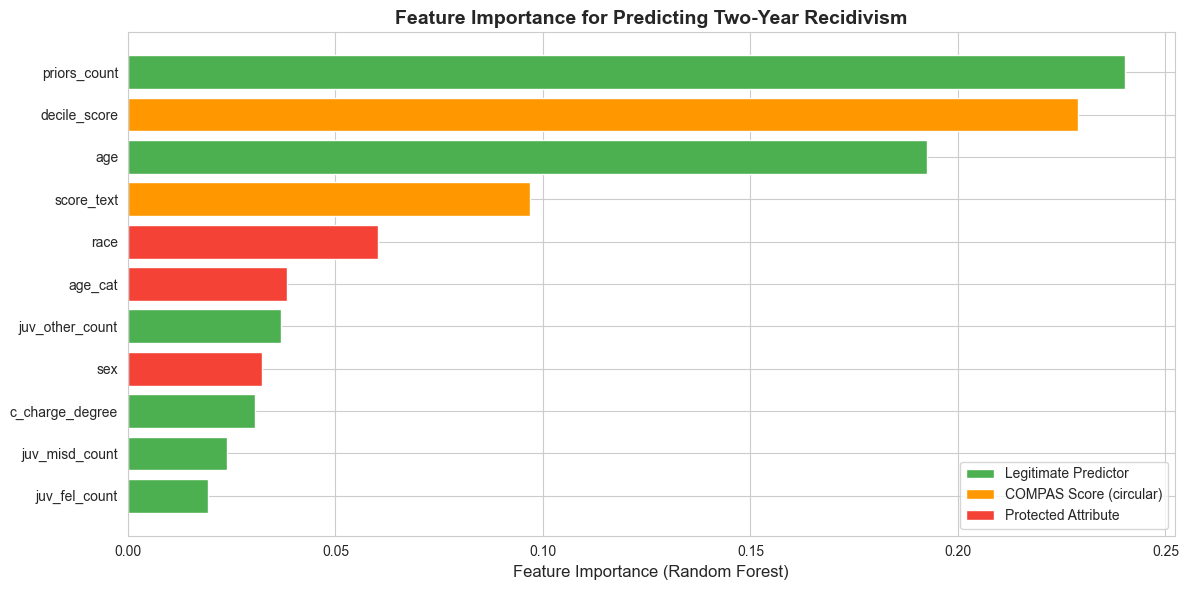


--- Feature Importance Ranking ---
  priors_count        : 0.2402
  decile_score        : 0.2290 << CIRCULAR
  age                 : 0.1926
  score_text          : 0.0968 << CIRCULAR
  race                : 0.0603 << PROTECTED
  age_cat             : 0.0382 << PROTECTED
  juv_other_count     : 0.0369
  sex                 : 0.0322 << PROTECTED
  c_charge_degree     : 0.0307
  juv_misd_count      : 0.0238
  juv_fel_count       : 0.0192


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare a clean feature set from the original data
df_feat = pd.read_csv("./datasets/compas-analysis/compas-scores-two-years.csv")

# Select all candidate features
feature_cols = ['age', 'sex', 'race', 'age_cat', 'priors_count',
                'juv_fel_count', 'juv_misd_count', 'juv_other_count',
                'c_charge_degree', 'decile_score', 'score_text']
target_col = 'two_year_recid'

df_feat = df_feat[feature_cols + [target_col]].dropna()
df_feat = df_feat[df_feat['c_charge_degree'].isin(['F', 'M'])]
df_feat = df_feat[df_feat['score_text'].isin(['Low', 'Medium', 'High'])]

# Encode categoricals
le_dict = {}
for col in ['sex', 'race', 'age_cat', 'c_charge_degree', 'score_text']:
    le = LabelEncoder()
    df_feat[col + '_enc'] = le.fit_transform(df_feat[col])
    le_dict[col] = le

# Features for model
model_features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
                  'juv_other_count', 'sex_enc', 'race_enc', 'age_cat_enc',
                  'c_charge_degree_enc', 'decile_score', 'score_text_enc']
feature_labels = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
                  'juv_other_count', 'sex', 'race', 'age_cat',
                  'c_charge_degree', 'decile_score', 'score_text']

X = df_feat[model_features].values
y = df_feat[target_col].values

# Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
rf.fit(X, y)
importances = rf.feature_importances_

# Sort and display
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
colors = []
protected_features = {'sex', 'race', 'age_cat'}
for i in sorted_idx:
    if feature_labels[i] in protected_features:
        colors.append('#F44336')  # Red for protected
    elif feature_labels[i] in ['decile_score', 'score_text']:
        colors.append('#FF9800')  # Orange for COMPAS scores
    else:
        colors.append('#4CAF50')  # Green for legitimate predictors

bars = ax.barh([feature_labels[i] for i in sorted_idx][::-1],
               importances[sorted_idx][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel("Feature Importance (Random Forest)", fontsize=12)
ax.set_title("Feature Importance for Predicting Two-Year Recidivism", fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Legitimate Predictor'),
                   Patch(facecolor='#FF9800', label='COMPAS Score (circular)'),
                   Patch(facecolor='#F44336', label='Protected Attribute')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Feature Importance Ranking ---")
for i in sorted_idx:
    tag = ""
    if feature_labels[i] in protected_features:
        tag = " << PROTECTED"
    elif feature_labels[i] in ['decile_score', 'score_text']:
        tag = " << CIRCULAR"
    print(f"  {feature_labels[i]:20s}: {importances[i]:.4f}{tag}")

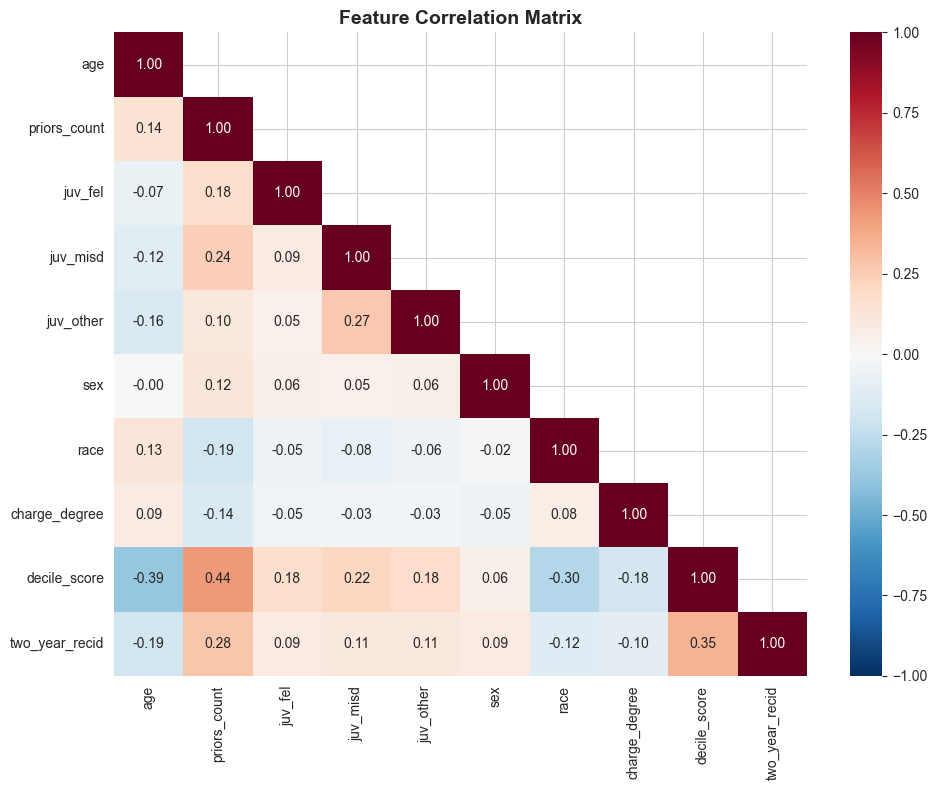


--- Correlation with two_year_recid ---
  decile_score        : +0.3507
  priors_count        : +0.2751
  age                 : -0.1903
  race                : -0.1231
  juv_misd            : +0.1093
  juv_other           : +0.1080
  charge_degree       : -0.1045
  juv_fel             : +0.0925
  sex                 : +0.0922


In [20]:
# --- Correlation heatmap of features vs. target ---
corr_cols = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
             'juv_other_count', 'sex_enc', 'race_enc', 'c_charge_degree_enc',
             'decile_score', 'two_year_recid']
corr_labels = ['age', 'priors_count', 'juv_fel', 'juv_misd',
               'juv_other', 'sex', 'race', 'charge_degree',
               'decile_score', 'two_year_recid']

corr_matrix = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=corr_labels, yticklabels=corr_labels)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = df_feat[corr_cols].corr()['two_year_recid'].drop('two_year_recid')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print("\n--- Correlation with two_year_recid ---")
for feat, corr_val in target_corr.items():
    idx = corr_cols.index(feat)
    label = corr_labels[idx]
    print(f"  {label:20s}: {corr_val:+.4f}")

In [21]:
# --- Does including race actually improve prediction accuracy? ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Model WITHOUT protected attributes and WITHOUT COMPAS scores
fair_features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
                 'juv_other_count', 'c_charge_degree_enc']
fair_labels = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count',
               'juv_other_count', 'c_charge_degree']

scaler = StandardScaler()
X_fair = scaler.fit_transform(df_feat[fair_features].values)
y_all = df_feat[target_col].values

lr_fair = LogisticRegression(random_state=42, max_iter=1000)
lr_fair.fit(X_fair, y_all)

# Model WITH race
with_race_features = fair_features + ['race_enc']
scaler2 = StandardScaler()
X_race = scaler2.fit_transform(df_feat[with_race_features].values)
lr_race = LogisticRegression(random_state=42, max_iter=1000)
lr_race.fit(X_race, y_all)

# Model WITH race + sex
with_all_features = fair_features + ['race_enc', 'sex_enc']
scaler3 = StandardScaler()
X_all_prot = scaler3.fit_transform(df_feat[with_all_features].values)
lr_all_prot = LogisticRegression(random_state=42, max_iter=1000)
lr_all_prot.fit(X_all_prot, y_all)

print("=" * 65)
print("FEATURE NECESSITY: Does including protected attributes help?")
print("=" * 65)
print(f"\n  Model WITHOUT race/sex (fair features only):")
print(f"    Accuracy: {accuracy_score(y_all, lr_fair.predict(X_fair)):.4f}")
print(f"    AUC-ROC:  {roc_auc_score(y_all, lr_fair.predict_proba(X_fair)[:,1]):.4f}")

print(f"\n  Model WITH race added:")
print(f"    Accuracy: {accuracy_score(y_all, lr_race.predict(X_race)):.4f}")
print(f"    AUC-ROC:  {roc_auc_score(y_all, lr_race.predict_proba(X_race)[:,1]):.4f}")

print(f"\n  Model WITH race + sex:")
print(f"    Accuracy: {accuracy_score(y_all, lr_all_prot.predict(X_all_prot)):.4f}")
print(f"    AUC-ROC:  {roc_auc_score(y_all, lr_all_prot.predict_proba(X_all_prot)[:,1]):.4f}")

print(f"\n  -> Including race/sex provides negligible accuracy improvement,")
print(f"     but introduces significant fairness concerns.")

# Show coefficients for the fair model
print(f"\n--- Fair Model Coefficients (standardized) ---")
coefs = sorted(zip(fair_labels, lr_fair.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for label, coef in coefs:
    print(f"  {label:20s}: {coef:+.4f}")

FEATURE NECESSITY: Does including protected attributes help?

  Model WITHOUT race/sex (fair features only):
    Accuracy: 0.6770
    AUC-ROC:  0.7236

  Model WITH race added:
    Accuracy: 0.6770
    AUC-ROC:  0.7233

  Model WITH race + sex:
    Accuracy: 0.6778
    AUC-ROC:  0.7246

  -> Including race/sex provides negligible accuracy improvement,
     but introduces significant fairness concerns.

--- Fair Model Coefficients (standardized) ---
  priors_count        : +0.7360
  age                 : -0.5299
  juv_other_count     : +0.1008
  c_charge_degree     : -0.0883
  juv_fel_count       : +0.0868
  juv_misd_count      : +0.0119


---
## 12. Conclusion: Which Features Are Necessary?

Based on the full EDA — logistic regression, Cox models, confusion matrix analysis, Random Forest importance, and correlation analysis — here is the determination of which features are necessary for a valid and fair recidivism model.

### Essential Features (Legitimate Predictors)
| Feature | Justification |
|---------|---------------|
| **`priors_count`** | Strongest predictor of recidivism across all analyses. Highest correlation and RF importance. |
| **`age`** | Strong predictor — younger defendants recidivate at higher rates. Confirmed by RF, logistic regression, and Cox models. |
| **`juv_fel_count`** | Juvenile felony history adds meaningful predictive signal beyond `priors_count`. |
| **`juv_misd_count`** | Modest but real contribution. |
| **`juv_other_count`** | Minor contribution, but may help at the margins. |
| **`c_charge_degree`** | Felony vs. misdemeanor distinguishes offense severity meaningfully. |

### Protected Attributes (Should NOT be model features)
| Feature | Reason to Exclude |
|---------|-------------------|
| **`race`** | Core finding: 45–77% overprediction for Black defendants with negligible accuracy gain. |
| **`sex`** | 19.4% bias against women; High-risk women recidivate at rates comparable to Medium-risk men. |
| **`age_cat`** | Categorical bins amplify age bias (2.5–7.4x odds ratios). Use continuous `age` instead. |

### Circular Features (Invalid for fairness evaluation)
| Feature | Reason |
|---------|--------|
| **`decile_score`** | This IS the COMPAS score — using it to predict recidivism is circular. |
| **`score_text`** | Derived from `decile_score`, same circularity. |

### Key Takeaway
A model using only **`priors_count`, `age`, `juv_fel_count`, `juv_misd_count`, `juv_other_count`, and `c_charge_degree`** achieves comparable predictive accuracy to COMPAS (~63–66% concordance) without encoding racial bias. The COMPAS algorithm's bias stems from producing **systematically different error rates** across racial groups: Black defendants are ~2x more likely to be false positives, while White defendants are ~1.7x more likely to be false negatives.

# COMPAS Recidivism Dataset — EDA Summary

This notebook summarizes the key findings, features, and exploratory data analysis performed on the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) dataset, originally investigated by ProPublica.

**Datasets used:**
- `compas-scores-two-years.csv` — Filtered dataset for two-year general recidivism analysis
- `compas-scores-two-years-violent.csv` — Violent recidivism subset
- `cox-parsed.csv` / `cox-violent-parsed.csv` — Survival analysis datasets

**Primary research question:** Does the COMPAS risk assessment tool exhibit racial bias in predicting recidivism?